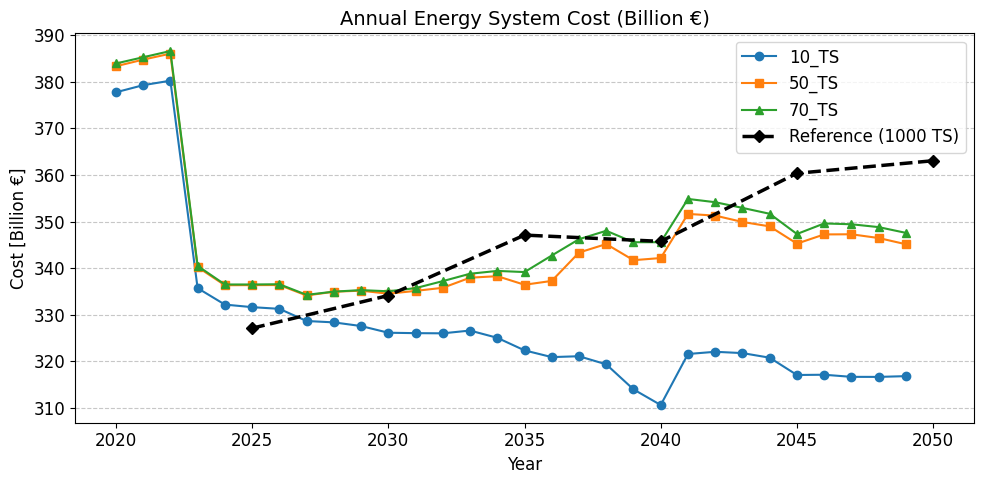

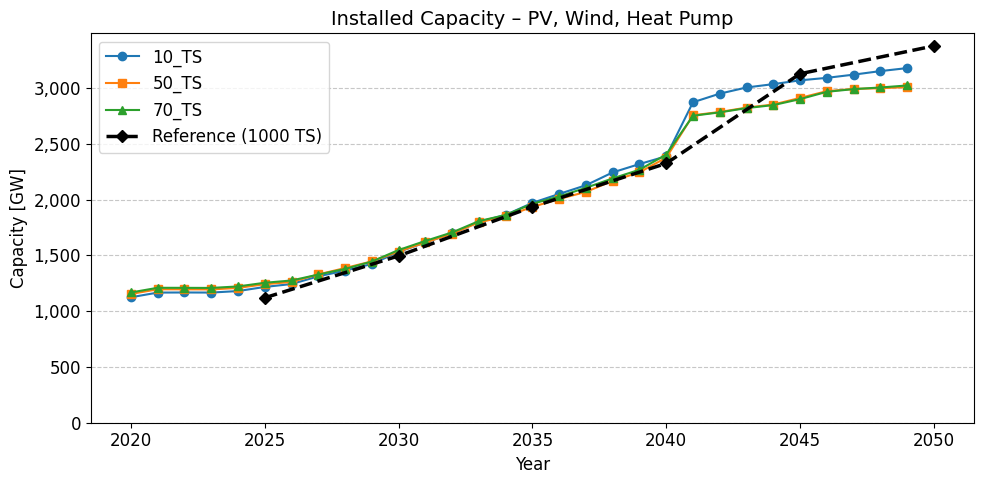

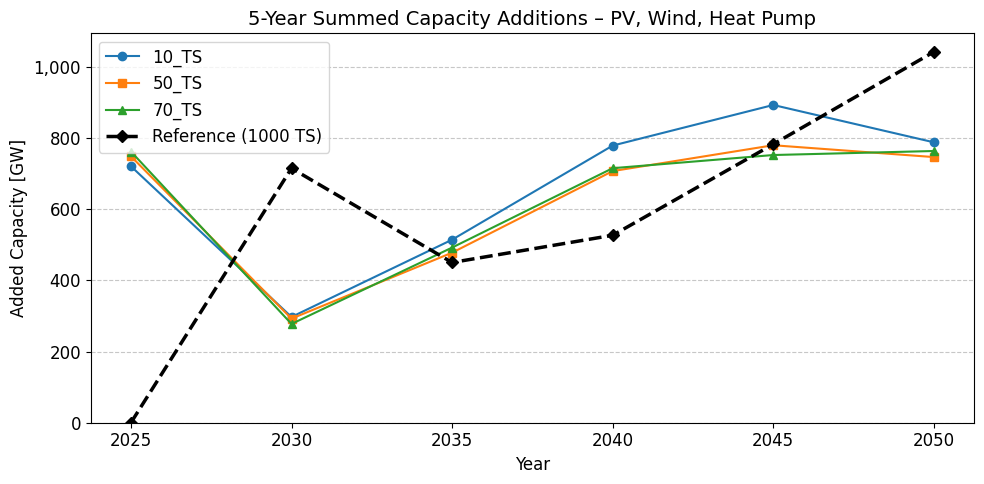

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mtick
from zen_garden.postprocess.results import Results

# === Dataset Setup ===
input_datasets = [
    '2020_10ts_30a',
    '2020_50ts_30a_1',
    '2020_70ts_30a',
    'energy_transition_example_output',
]

input_labels = ['10_TS', '50_TS', '70_TS', 'example_1000_TS']

base_path = r"C:\Users\nicol\OneDrive\Dokumente\ZEN-garden_SP\Data\energy_sytem\outputs"
paths_input = [os.path.join(base_path, name) for name in input_datasets]
results_input = [Results(path) for path in paths_input]

input_start_years = {
    '10_TS': 2020,
    '50_TS': 2020,
    '70_TS': 2020,
    'example_1000_TS': 2025,
}
input_intervals = {
    'example_1000_TS': 5,
}
conversion_techs = ['photovoltaics', 'wind_onshore', 'heat_pump']

# === Save path ===
save_path = r"C:\Users\nicol\OneDrive\Desktop\Semester_project\Plots_and_Figures\ESM_plots\ts_resolution_comparison"
os.makedirs(save_path, exist_ok=True)

# === Styling ===
plt.rcParams.update({'font.size': 12})

marker_styles = {
    '10_TS': 'o',
    '50_TS': 's',
    '70_TS': '^',
    'example_1000_TS': 'D'
}

colors = {
    '10_TS': '#1f77b4',
    '50_TS': '#ff7f0e',
    '70_TS': '#2ca02c',
    'example_1000_TS': 'black'
}

# === Cost Comparison ===
try:
    plt.figure(figsize=(10, 5))
    for res, label in zip(results_input, input_labels):
        cost = res.get_total('cost_total')  # in MEUR
        start_year = input_start_years[label]
        step = input_intervals.get(label, 1)
        cost.index = list(range(start_year, start_year + len(cost) * step, step))
        cost_in_beuro = cost * 1e6 / 1e9

        plt.plot(cost_in_beuro.index, cost_in_beuro.values,
                 marker=marker_styles[label],
                 linestyle='--' if label == 'example_1000_TS' else '-',
                 linewidth=2.5 if label == 'example_1000_TS' else 1.5,
                 color=colors[label],
                 label='Reference (1000 TS)' if label == 'example_1000_TS' else label)

    plt.title('Annual Energy System Cost (Billion €)', fontsize=14)
    plt.xlabel('Year')
    plt.ylabel('Cost [Billion €]')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, "energy_system_cost_ts_resolution.pdf"), format='pdf', bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Error plotting cost_total: {e}")

# === Reusable Plot Function ===
def plot_series(title, y_label, component, tech_filter=None, binning=False, ylim_bottom=0):
    try:
        plt.figure(figsize=(10, 5))
        for res, label in zip(results_input, input_labels):
            df = res.get_total(component)
            start_year = input_start_years[label]
            step = input_intervals.get(label, 1)
            df.columns = list(range(start_year, start_year + df.shape[1] * step, step))

            if 'technology' in df.index.names:
                df = df.loc[df.index.get_level_values('technology').isin(tech_filter)]

            total = df.sum(axis=0)

            if binning:
                bin_edges = [2020, 2025, 2030, 2035, 2040, 2045, 2050]
                bin_labels = [2025, 2030, 2035, 2040, 2045, 2050]
                binned = pd.cut(total.index, bins=bin_edges, labels=bin_labels, right=False)
                total = total.groupby(binned, observed=False).sum()
                total.index = total.index.astype(int)

            plt.plot(total.index, total.values,
                     marker=marker_styles[label],
                     linestyle='--' if label == 'example_1000_TS' else '-',
                     linewidth=2.5 if label == 'example_1000_TS' else 1.5,
                     color=colors[label],
                     label='Reference (1000 TS)' if label == 'example_1000_TS' else label)

        plt.title(title, fontsize=14)
        plt.xlabel('Year')
        plt.ylabel(y_label)
        plt.ylim(bottom=ylim_bottom)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
        plt.legend(loc='upper left')
        plt.tight_layout()
        filename = title.replace("–", "-").replace(" ", "_").replace("(", "").replace(")", "").lower()
        plt.savefig(os.path.join(save_path, f"{filename}.pdf"), format='pdf', bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"Error plotting {title.lower()}: {e}")

# === Plot Calls ===
plot_series(
    title='Installed Capacity – PV, Wind, Heat Pump',
    y_label='Capacity [GW]',
    component="capacity",
    tech_filter=conversion_techs,
    ylim_bottom=0
)

plot_series(
    title='5-Year Summed Capacity Additions – PV, Wind, Heat Pump',
    y_label='Added Capacity [GW]',
    component="capacity_addition",
    tech_filter=conversion_techs,
    binning=True,
    ylim_bottom=0
)
